# H4 - Seasonality
Does rental performance change depending on the month/season and does this follow the broader tourism season in Barcelona?

In [ ]:
"""
Airbnb data
     ↓
Load & prepare
     ↓
Monthly Airbnb performance
     ↓
Occupancy + ADR + RevPAR
     ↓
        +
INE data
     ↓
Total tourist nights
     ↓
      COMPARE
     ↓
Seasonality
     ↓
 H4 CONCLUSION
"""

In [2]:
import pandas as pd

In [4]:
# Load the Airbnb and INE datasets
airbnb_df = pd.read_csv("airbnb_final.csv")
ine_df = pd.read_csv("ine_final.csv")

In [5]:
airbnb_df.head()

,listing_id,room_type,latitude,longitude,guests,bedrooms,beds,baths,property_type,neighborhood,month_date,available_days,occupancy,avg_daily_rate,revenue,active,booking_lead_time_avg,length_of_stay_avg,revpar
0,14948804,private_room,41.40698,2.18241,2.0,1.0,1.0,1.0,Apartment & Condo,Sant Martí,2021-03-01,31,0.000,24.4,0.0,False,NaN,NaN,0.000000
1,14948804,private_room,41.40698,2.18241,2.0,1.0,1.0,1.0,Apartment & Condo,Sant Martí,2021-04-01,30,0.000,24.3,0.0,False,NaN,NaN,0.000000
2,14948804,private_room,41.40698,2.18241,2.0,1.0,1.0,1.0,Apartment & Condo,Sant Martí,2021-05-01,26,0.161,24.8,125.0,True,NaN,NaN,4.032258
3,14948804,private_room,41.40698,2.18241,2.0,1.0,1.0,1.0,Apartment & Condo,Sant Martí,2021-06-01,30,0.000,24.7,0.0,True,NaN,NaN,0.000000
4,14948804,private_room,41.40698,2.18241,2.0,1.0,1.0,1.0,Apartment & Condo,Sant Martí,2021-07-01,31,0.000,25.0,0.0,True,NaN,NaN,0.000000


In [6]:
ine_df.head()

,date,total_travellers,travellers_spain,travellers_abroad,total_nights,nights_spain,nights_abroad
0,2021-01-01,64426.0,42324.0,22102.0,124403.0,75385.0,49018.0
1,2021-02-01,77845.0,55121.0,22724.0,141119.0,89137.0,51982.0
2,2021-03-01,96346.0,64146.0,32200.0,181077.0,106209.0,74868.0
3,2021-04-01,99789.0,59229.0,40560.0,210963.0,107864.0,103099.0
4,2021-05-01,162954.0,75615.0,87339.0,360912.0,137286.0,223626.0


In [7]:
# Convert the Airbnb month_date column into a datetime column
airbnb_df["month_date"] = pd.to_datetime(airbnb_df["month_date"])

# Convert the INE date column into a datetime column
ine_df["date"] = pd.to_datetime(ine_df["date"])

In [8]:
print(airbnb_df["month_date"].dtype)
print(ine_df["date"].dtype)

datetime64[us]
datetime64[us]


In [9]:
# Check the first and last month in the Airbnb data
print("Airbnb first month:", airbnb_df["month_date"].min())
print("Airbnb last month:", airbnb_df["month_date"].max())

# Check the first and last month in the INE data
print("INE first month:", ine_df["date"].min())
print("INE last month:", ine_df["date"].max())

Airbnb first month: 2021-03-01 00:00:00
Airbnb last month: 2026-02-01 00:00:00
INE first month: 2021-01-01 00:00:00
INE last month: 2026-08-01 00:00:00


In [10]:
# Keep only the INE months that are also available in the Airbnb data
ine_df = ine_df[
    (ine_df["date"] >= "2021-03-01") & (ine_df["date"] <= "2026-02-01")
].copy()

# Check the new INE date range
print("INE first month:", ine_df["date"].min())
print("INE last month:", ine_df["date"].max())
print("Number of months:", len(ine_df))

INE first month: 2021-03-01 00:00:00
INE last month: 2026-02-01 00:00:00
Number of months: 60


In [11]:
# Calculate the average Airbnb performance for each month
airbnb_monthly = (
    airbnb_df.groupby("month_date")
    .agg(
        occupancy=("occupancy", "mean"),
        avg_daily_rate=("avg_daily_rate", "mean"),
        revpar=("revpar", "mean"),
    )
    .reset_index()
)

# Look at the monthly Airbnb data
airbnb_monthly.head()

,month_date,occupancy,avg_daily_rate,revpar
0,2021-03-01,0.356933,110.100000,41.169600
1,2021-04-01,0.375385,114.940771,41.847870
2,2021-05-01,0.417580,118.967546,49.732840
3,2021-06-01,0.452888,124.269371,57.723800
4,2021-07-01,0.486554,128.162272,62.364654


In [12]:
# Keep only the month and total tourist nights from the INE data
ine_monthly = ine_df[["date", "total_nights"]].copy()

In [13]:
# Rename the INE date column to match the Airbnb dataset
ine_monthly = ine_monthly.rename(columns={"date": "month_date"})

ine_monthly.head()

,month_date,total_nights
2,2021-03-01,181077.0
3,2021-04-01,210963.0
4,2021-05-01,360912.0
5,2021-06-01,552505.0
6,2021-07-01,958979.0


In [14]:
# Combine Airbnb and INE data using the month
h4_data = pd.merge(airbnb_monthly, ine_monthly, on="month_date", how="inner")

h4_data.head()

,month_date,occupancy,avg_daily_rate,revpar,total_nights
0,2021-03-01,0.356933,110.100000,41.169600,181077.0
1,2021-04-01,0.375385,114.940771,41.847870,210963.0
2,2021-05-01,0.417580,118.967546,49.732840,360912.0
3,2021-06-01,0.452888,124.269371,57.723800,552505.0
4,2021-07-01,0.486554,128.162272,62.364654,958979.0


In [15]:
# Check for missing values in the H4 dataset
h4_data.isnull().sum()

month_date        0
occupancy         0
avg_daily_rate    0
revpar            0
total_nights      0
dtype: int64

## Season Analysis

In [16]:
# Calculate the average occupancy for each month
h4_data[["month_date", "occupancy"]].head(12)

,month_date,occupancy
0,2021-03-01,0.356933
1,2021-04-01,0.375385
2,2021-05-01,0.417580
3,2021-06-01,0.452888
4,2021-07-01,0.486554
5,2021-08-01,0.521755
6,2021-09-01,0.507568
7,2021-10-01,0.490868
8,2021-11-01,0.455584
9,2021-12-01,0.386972


In [17]:
# Extract the calendar month from the date
h4_data["month"] = h4_data["month_date"].dt.month

# Check the month column
h4_data[["month_date", "month"]].head(12)

,month_date,month
0,2021-03-01,3
1,2021-04-01,4
2,2021-05-01,5
3,2021-06-01,6
4,2021-07-01,7
5,2021-08-01,8
6,2021-09-01,9
7,2021-10-01,10
8,2021-11-01,11
9,2021-12-01,12


In [18]:
# Calculate the average Airbnb performance for each calendar month
seasonality = (
    h4_data.groupby("month")
    .agg(
        occupancy=("occupancy", "mean"),
        avg_daily_rate=("avg_daily_rate", "mean"),
        revpar=("revpar", "mean"),
        total_nights=("total_nights", "mean"),
    )
    .reset_index()
)

seasonality

,month,occupancy,avg_daily_rate,revpar,total_nights
0,1,0.298145,151.476479,45.617875,1268459.2
1,2,0.335325,160.177932,56.509619,1418901.8
2,3,0.384881,152.470075,62.703854,1379084.2
3,4,0.421259,162.235251,75.720619,1556680.4
4,5,0.460568,182.095965,93.495332,1651686.4
5,6,0.451760,185.831295,94.805732,1667003.2
6,7,0.487062,183.965281,98.476226,1875440.6
7,8,0.484654,178.763228,92.565983,1979760.4
8,9,0.463321,170.609774,83.742498,1711681.2
9,10,0.444879,172.511095,84.328174,1817234.2


In [19]:
# Convert month numbers into month names
seasonality["month_name"] = pd.to_datetime(
    seasonality["month"], format="%m"
).dt.month_name()

# Check the month names
seasonality[["month", "month_name"]]

,month,month_name
0,1,January
1,2,February
2,3,March
3,4,April
4,5,May
5,6,June
6,7,July
7,8,August
8,9,September
9,10,October


In [20]:
# Convert occupancy from a decimal to a percentage
seasonality["occupancy_pct"] = seasonality["occupancy"] * 100

# Check the occupancy percentages
seasonality[["month_name", "occupancy_pct"]]

,month_name,occupancy_pct
0,January,29.814465
1,February,33.532496
2,March,38.488104
3,April,42.125914
4,May,46.056796
5,June,45.175954
6,July,48.706204
7,August,48.465402
8,September,46.332083
9,October,44.487889


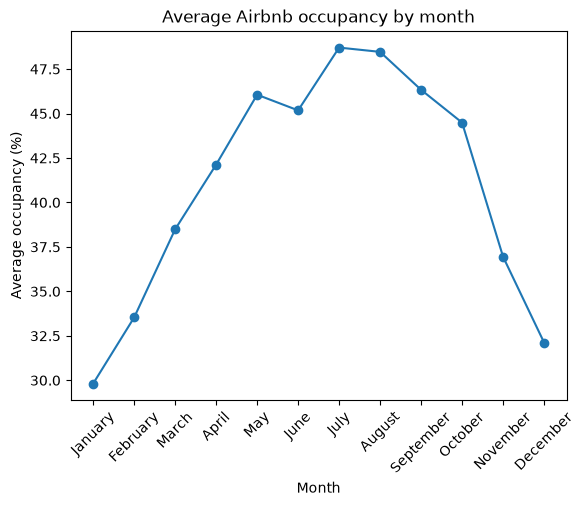

In [21]:
# Plot average Airbnb occupancy for each month
import matplotlib.pyplot as plt

plt.plot(seasonality["month_name"], seasonality["occupancy_pct"], marker="o")

plt.xlabel("Month")
plt.ylabel("Average occupancy (%)")
plt.title("Average Airbnb occupancy by month")
plt.xticks(rotation=45)
plt.show()

## H4 — Seasonality: Airbnb Occupancy

The chart shows a clear seasonal pattern in Airbnb occupancy.

Occupancy increases from winter to summer, reaching its highest level in **July (48.7%)** and remaining high in **August (48.5%)**.

After summer, occupancy gradually decreases again, reaching its lowest level in **January (29.8%)**.

This suggests that Airbnb demand in Barcelona is generally higher during the summer months and lower during the winter months.

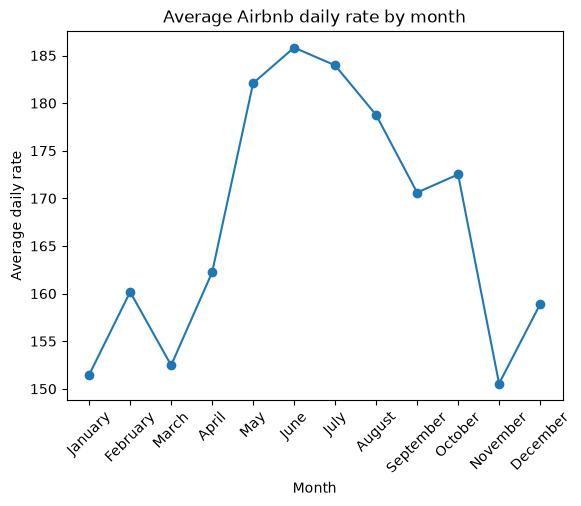

In [22]:
# Plot the average daily rate for each month
plt.plot(seasonality["month_name"], seasonality["avg_daily_rate"], marker="o")

plt.xlabel("Month")
plt.ylabel("Average daily rate")
plt.title("Average Airbnb daily rate by month")
plt.xticks(rotation=45)
plt.show()

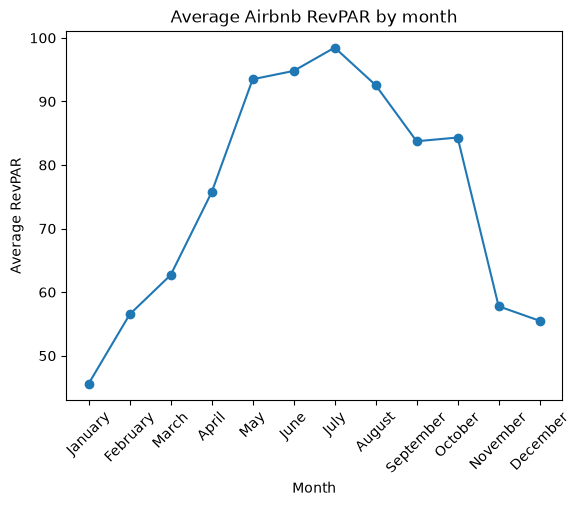

In [23]:
# Plot the average RevPAR for each month
plt.plot(seasonality["month_name"], seasonality["revpar"], marker="o")

plt.xlabel("Month")
plt.ylabel("Average RevPAR")
plt.title("Average Airbnb RevPAR by month")
plt.xticks(rotation=45)
plt.show()

## H4 — Seasonality: Rental Performance

RevPAR shows a clear seasonal pattern in Airbnb performance.

The lowest average RevPAR occurs in **January (45.6)**. It then increases through spring and reaches its highest level in **July (98.5)**.

RevPAR remains relatively high during the summer and early autumn before decreasing again in the later autumn and winter months.

This suggests that Airbnb rental performance is generally stronger during the warmer and busier months of the year.

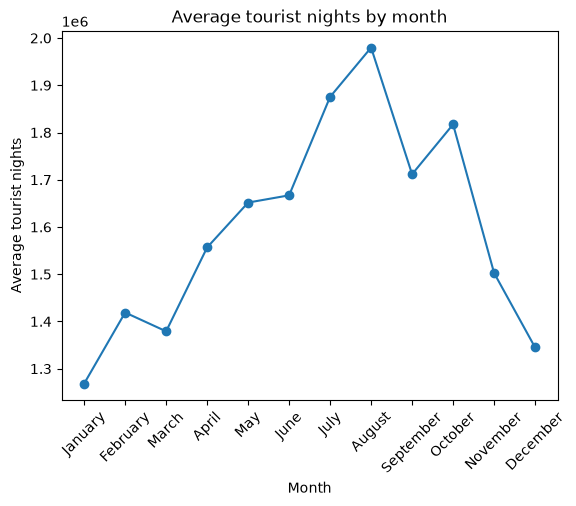

In [24]:
# Plot average tourist nights for each month
plt.plot(seasonality["month_name"], seasonality["total_nights"], marker="o")

plt.xlabel("Month")
plt.ylabel("Average tourist nights")
plt.title("Average tourist nights by month")
plt.xticks(rotation=45)
plt.show()

In [25]:
# Check the tourist nights for each month
seasonality[["month_name", "total_nights"]]

,month_name,total_nights
0,January,1268459.2
1,February,1418901.8
2,March,1379084.2
3,April,1556680.4
4,May,1651686.4
5,June,1667003.2
6,July,1875440.6
7,August,1979760.4
8,September,1711681.2
9,October,1817234.2


In [26]:
# Compare the main H4 indicators by month
seasonality[["month_name", "occupancy_pct", "avg_daily_rate", "revpar", "total_nights"]]

,month_name,occupancy_pct,avg_daily_rate,revpar,total_nights
0,January,29.814465,151.476479,45.617875,1268459.2
1,February,33.532496,160.177932,56.509619,1418901.8
2,March,38.488104,152.470075,62.703854,1379084.2
3,April,42.125914,162.235251,75.720619,1556680.4
4,May,46.056796,182.095965,93.495332,1651686.4
5,June,45.175954,185.831295,94.805732,1667003.2
6,July,48.706204,183.965281,98.476226,1875440.6
7,August,48.465402,178.763228,92.565983,1979760.4
8,September,46.332083,170.609774,83.742498,1711681.2
9,October,44.487889,172.511095,84.328174,1817234.2


## H4 — Seasonality: Final Conclusion

Rental performance clearly changes throughout the year.

- Airbnb occupancy and RevPAR generally increase from winter into summer, with **July showing the highest occupancy (48.7%) and RevPAR (98.5)**. January has the lowest occupancy (29.8%) and RevPAR (45.6%).

- Tourism demand follows a similar seasonal pattern. **August has the highest average number of tourist nights (1.98 million)**, while tourist activity is lower during the winter months.

- ADR also varies throughout the year, reaching its highest average in **June (185.83)**.

Overall, the results show that **seasonality plays an important role in short-term rental performance in Barcelona**, with summer and the surrounding months generally showing stronger performance than winter. The Airbnb pattern broadly follows the wider tourism pattern observed in the INE data.

These results describe relationships and seasonal patterns in the data and do not prove that seasonality directly causes changes in Airbnb performance.
